In [1]:
import os
import matplotlib.pyplot as plt 
from PIL import Image
from collections import Counter


data_dir = "../data/raw/garbage-dataset/standardized_256"
classes = sorted(os.listdir(data_dir))
for c in classes:
    class_path = os.path.join(data_dir,c)
    if os.path.isdir(class_path):
        n = len(os.listdir(class_path))
        print(f"{c}: {n} images")

battery: 756 images
biological: 699 images
cardboard: 1411 images
clothes: 1892 images
glass: 1736 images
metal: 930 images
paper: 1336 images
plastic: 1597 images
shoes: 1449 images
trash: 453 images


<function matplotlib.pyplot.show(close=None, block=None)>

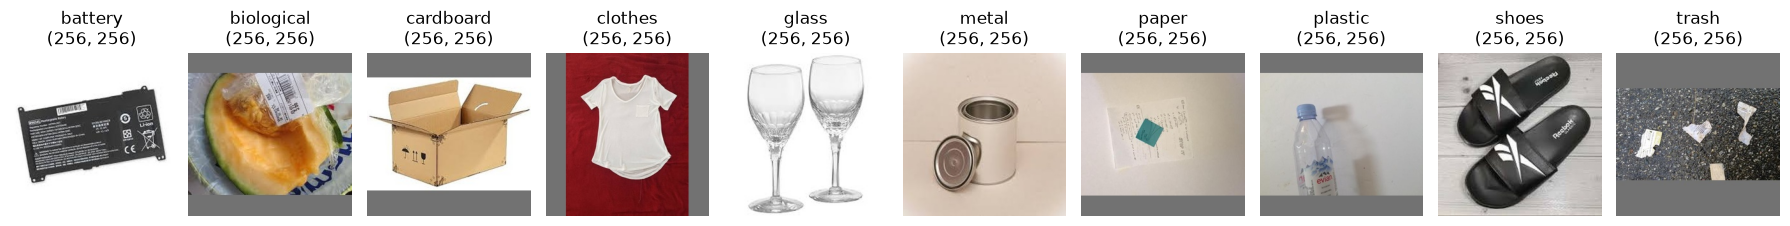

In [5]:
fig, axes = plt.subplots(1,len(classes), figsize=(18,3))
for ax, c in zip(axes, classes):
    class_path = os.path.join(data_dir,c)
    first_image = os.listdir(class_path)[0]
    img = Image.open(os.path.join(class_path, first_image))
    ax.imshow(img)
    ax.set_title(f"{c}\n{img.size}")
    ax.axis("off")
plt.tight_layout()
plt.show

In [ ]:
# Visual style: unlike TrashNet's uniformly studio-style images, GD shows a mix of 
# clean/staged photos (e.g. battery, glass, metal) and real-world/contextual photos 
# (e.g. cardboard, trash, clothes) — consistent with its stated construction from both 
# web-sourced and app-submitted (DWaste) images. This mix likely improves generalization 
# versus TrashNet alone, but should be verified with a larger multi-image sample per class 
# before drawing firm conclusions.

In [7]:
sizes = Counter ()
for c in classes:
    class_path = os.path.join(data_dir,c)
    for fname in os.listdir(class_path):
        with Image.open(os.path.join(class_path,fname)) as img:
            sizes[img.size]+=1
print(sizes)

Counter({(256, 256): 12259})


In [9]:
import torch
from torchvision import transforms
from torch.utils.data import DataLoader, random_split
from torchvision.datasets import ImageFolder

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [10]:
full_dataset = ImageFolder(data_dir)

train_size = int(0.7*len(full_dataset))
val_size = int(0.15*len(full_dataset))
test_size = int(len(full_dataset) - train_size - val_size)

generator = torch.Generator().manual_seed(42)
train_subset , val_subset , test_subset = random_split(full_dataset , [train_size, val_size, test_size], generator=generator)

train_ds = ImageFolder(data_dir, transform=train_transforms)

val_ds = ImageFolder(data_dir, transform=eval_transforms)

test_ds = ImageFolder(data_dir, transform=eval_transforms)

train_ds = torch.utils.data.Subset(train_ds , train_subset.indices)

val_ds = torch.utils.data.Subset(val_ds, val_subset.indices)

test_ds = torch.utils.data.Subset(test_ds, test_subset.indices)

train_loader = DataLoader(train_ds,batch_size=32, shuffle=True, num_workers=2)

val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2)

test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2)

print(f"Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")

images, labels = next(iter(train_loader))
print(images.shape, labels.shape)


Train: 8581, Val: 1838, Test: 1840
torch.Size([32, 3, 224, 224]) torch.Size([32])


In [14]:
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

model_gd = resnet18(weights=ResNet18_Weights.DEFAULT)

for param in model_gd.parameters():
    param.requires_grad = False

model_gd.fc = nn.Linear(model_gd.fc.in_features, len(classes))
model_gd = model_gd.to(device)

print(model_gd.fc)

cpu
Linear(in_features=512, out_features=10, bias=True)


In [15]:
criterion_gd = nn.CrossEntropyLoss()
optimizer_gd = torch.optim.Adam(model_gd.fc.parameters(), lr=0.001)


In [16]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    return running_loss / total, correct / total

In [17]:
num_epochs = 15
history_gd = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model_gd, train_loader, criterion_gd, optimizer_gd, device)
    val_loss, val_acc = evaluate(model_gd, val_loader, criterion_gd, device)

    history_gd["train_loss"].append(train_loss)
    history_gd["train_acc"].append(train_acc)
    history_gd["val_loss"].append(val_loss)
    history_gd["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            "model_state_dict": model_gd.state_dict(),
            "history": history_gd,
            "classes": classes,
            "epoch": epoch + 1,
        }, "../models/resnet18_gd_v1_best.pt")
        print(f"  -> New best model saved (val_acc={val_acc:.4f})")

Epoch 1/15 | Train Loss: 1.0568, Train Acc: 0.6743 | Val Loss: 0.6655, Val Acc: 0.7884
  -> New best model saved (val_acc=0.7884)
Epoch 2/15 | Train Loss: 0.6544, Train Acc: 0.7906 | Val Loss: 0.5503, Val Acc: 0.8351
  -> New best model saved (val_acc=0.8351)
Epoch 3/15 | Train Loss: 0.5638, Train Acc: 0.8128 | Val Loss: 0.5219, Val Acc: 0.8330
Epoch 4/15 | Train Loss: 0.5470, Train Acc: 0.8163 | Val Loss: 0.5011, Val Acc: 0.8362
  -> New best model saved (val_acc=0.8362)
Epoch 5/15 | Train Loss: 0.5306, Train Acc: 0.8181 | Val Loss: 0.4959, Val Acc: 0.8362
Epoch 6/15 | Train Loss: 0.4935, Train Acc: 0.8355 | Val Loss: 0.5088, Val Acc: 0.8297
Epoch 7/15 | Train Loss: 0.4948, Train Acc: 0.8314 | Val Loss: 0.4816, Val Acc: 0.8368
  -> New best model saved (val_acc=0.8368)
Epoch 8/15 | Train Loss: 0.4792, Train Acc: 0.8342 | Val Loss: 0.4513, Val Acc: 0.8515
  -> New best model saved (val_acc=0.8515)
Epoch 9/15 | Train Loss: 0.4822, Train Acc: 0.8346 | Val Loss: 0.4905, Val Acc: 0.8428
Ep

In [18]:
checkpoint = torch.load("../models/resnet18_gd_v1_best.pt", map_location=device)
model_gd.load_state_dict(checkpoint["model_state_dict"])
model_gd.eval()
print(f"Loaded best checkpoint from epoch {checkpoint['epoch']}")

Loaded best checkpoint from epoch 12


In [19]:
test_loss, test_acc = evaluate(model_gd, test_loader, criterion_gd, device)
print(f"GD v1 Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

GD v1 Test Loss: 0.4693, Test Accuracy: 0.8500
